Ignore the error as i have run the code again

In [4]:
import os
import numpy as np
import pydicom
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.transform import resize
from glob import glob

def load_dicom_series(series_path):
    slices = []
    for file in sorted(os.listdir(series_path)):
        if file.endswith(".dcm"):
            try:
                dcm = pydicom.dcmread(os.path.join(series_path, file), force=True)
                slices.append(dcm)
            except Exception as e:
                print(f"Failed to read {file}: {e}")
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    return slices

def convert_to_volume(slices):
    volume = np.stack([s.pixel_array for s in slices], axis=-1)
    volume = volume.astype(np.float32)
    return volume

def find_series_folders(patient_path):
    ct_series = None
    seg_series = None
    for root, dirs, files in os.walk(patient_path):
        dcm_files = [f for f in files if f.lower().endswith('.dcm')]
        if not dcm_files:
            continue
        try:
            first_dcm = pydicom.dcmread(os.path.join(root, dcm_files[0]), force=True)
            if hasattr(first_dcm, 'Modality'):
                if first_dcm.Modality == "CT" and ct_series is None:
                    ct_series = root
                elif first_dcm.Modality in ["SEG", "RTSTRUCT"] and seg_series is None:
                    seg_series = root
        except Exception as e:
            print(f"Error reading DICOM in {root}: {e}")
    return ct_series, seg_series

def extract_slices(patient_path, patient_id, output_size=(128, 128)):
    ct_series, seg_series = find_series_folders(patient_path)
    print(f"Patient {patient_id}: CT={ct_series}, SEG={seg_series}")
    if ct_series is None:
        print("No CT series found.")
        return
    
    ct_slices = load_dicom_series(ct_series)
    ct_volume = convert_to_volume(ct_slices)
    ct_volume = resize(ct_volume, (*output_size, ct_volume.shape[-1]), mode='constant')
    
    ct_volume = (ct_volume - np.min(ct_volume)) / (np.max(ct_volume) - np.min(ct_volume))

    output_path = os.path.join("preprocessed", patient_id)
    os.makedirs(output_path, exist_ok=True)
    np.save(os.path.join(output_path, "ct.npy"), ct_volume)
    print(f"Saved CT volume for {patient_id} -> {output_path}/ct.npy")
    
    # TODO: Add segmentation mask extraction if RTSTRUCT or SEG exists

def preprocess_dataset(root_dir):
    for patient_id in os.listdir(root_dir):
        patient_path = os.path.join(root_dir, patient_id)
        if os.path.isdir(patient_path):
            extract_slices(patient_path, patient_id)

# Root directory where LUNG-1 patient folders exist:
INPUT_DIR = r"C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics"
preprocess_dataset(INPUT_DIR)


Patient LUNG1-001: CT=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-001\09-18-2008-StudyID-NA-69331\0.000000-NA-82046, SEG=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-001\09-18-2008-StudyID-NA-69331\3.000000-NA-78236
Saved CT volume for LUNG1-001 -> preprocessed\LUNG1-001/ct.npy
Patient LUNG1-002: CT=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-002\01-01-2014-StudyID-NA-85095\1.000000-NA-61228, SEG=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-002\01-01-2014-StudyID-NA-85095\300.000000-Segmentation-5.421
Saved CT volume for LUNG1-002 -> preprocessed\LUNG1-002/ct.npy
Patient LUNG1-003: CT=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-003\01-01-2014-StudyID-NA-34270\1.000000-NA-28595, SEG=C:\\Lung_tumor_segmentation\\manifest-1603198545583\\NSCLC-Radiomics\LUNG1-003\01-01-2014-StudyID-NA-34270\300.000000-Segmentation-2.316
Saved CT volume for

KeyboardInterrupt: 

### Extract segmentation mask:

In [ ]:
# import os
# import shutil
# import numpy as np
# import SimpleITK as sitk
# import matplotlib.pyplot as plt
# from skimage.transform import resize

# # === Config ===
# DATASET_DIR = r"C:\Lung_tumor_segmentation\manifest-1603198545583\NSCLC-Radiomics"
# SEGMENTATION_DIR_NAME = "300.000000-Segmentation-"
# MASK_OUTPUT_DIR = "preprocessed_masks_128x128"
# CT_OUTPUT_DIR = "preprocessed_cts_128x128"
# TARGET_SIZE = (128, 128)

# # === Clean output dirs ===
# for out_dir in [MASK_OUTPUT_DIR, CT_OUTPUT_DIR]:
#     if os.path.exists(out_dir):
#         shutil.rmtree(out_dir)
#     os.makedirs(out_dir, exist_ok=True)

# def resize_slice(slice_2d, target_size):
#     """Resize a single 2D slice to target size"""
#     return resize(slice_2d, target_size, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

# def extract_seg_and_ct(patient_id):
#     patient_dir = os.path.join(DATASET_DIR, patient_id)
#     seg_found, ct_found = False, False
#     ct_candidate = None
#     max_dcm_files = 0

#     for root, dirs, files in os.walk(patient_dir):
#         # ---- SEGMENTATION ----
#         if SEGMENTATION_DIR_NAME in root:
#             dcm_files = [f for f in os.listdir(root) if f.endswith('.dcm')]
#             if not dcm_files:
#                 continue
#             seg_file = os.path.join(root, dcm_files[0])
#             seg = sitk.ReadImage(seg_file)
#             seg_array = sitk.GetArrayFromImage(seg)  # (slices, h, w)

#             for i in range(seg_array.shape[0]):
#                 resized_mask = resize_slice(seg_array[i], TARGET_SIZE)
#                 np.save(os.path.join(MASK_OUTPUT_DIR, f"{patient_id}_mask_slice_{i:03d}.npy"), resized_mask)
#                 if i == seg_array.shape[0] // 2:
#                     plt.imsave(os.path.join(MASK_OUTPUT_DIR, f"{patient_id}_mask_preview.png"), resized_mask, cmap='gray')
#             print(f"[INFO] Saved {seg_array.shape[0]} resized mask slices for {patient_id}")
#             seg_found = True

#         # ---- CT CANDIDATE DETECTION ----
#         if SEGMENTATION_DIR_NAME not in root:
#             dcm_files = [f for f in os.listdir(root) if f.endswith('.dcm')]
#             if len(dcm_files) > max_dcm_files:
#                 max_dcm_files = len(dcm_files)
#                 ct_candidate = (root, dcm_files)

#     # ---- CT EXTRACTION ----
#     if ct_candidate:
#         root, dcm_files = ct_candidate
#         dcm_files = sorted(dcm_files)
#         slices = []
#         for file in dcm_files:
#             path = os.path.join(root, file)
#             ds = sitk.ReadImage(path)
#             array = sitk.GetArrayFromImage(ds)[0]
#             slices.append(array)
#         ct_array = np.array(slices)

#         for i in range(ct_array.shape[0]):
#             resized_ct = resize_slice(ct_array[i], TARGET_SIZE)
#             np.save(os.path.join(CT_OUTPUT_DIR, f"{patient_id}_ct_slice_{i:03d}.npy"), resized_ct)
#             if i == ct_array.shape[0] // 2:
#                 plt.imsave(os.path.join(CT_OUTPUT_DIR, f"{patient_id}_ct_preview.png"), resized_ct, cmap='gray')
#         print(f"[INFO] Saved {ct_array.shape[0]} resized CT slices for {patient_id}")
#         ct_found = True

#     if not seg_found:
#         print(f"[WARNING] No segmentation found for {patient_id}")
#     if not ct_found:
#         print(f"[WARNING] No CT slices found for {patient_id}")

# # === Run all patients ===
# for patient_id in os.listdir(DATASET_DIR):
#     if os.path.isdir(os.path.join(DATASET_DIR, patient_id)):
#         extract_seg_and_ct(patient_id)


### the below code will skip the Empty Mask and will create the balanced dataset

In [ ]:
import os
import shutil
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from skimage.transform import resize

# === Config ===
DATASET_DIR = r"C:\Lung_tumor_segmentation\manifest-1603198545583\NSCLC-Radiomics"
SEGMENTATION_DIR_NAME = "300.000000-Segmentation-"
MASK_OUTPUT_DIR = "preprocessed_masks_128x128"
CT_OUTPUT_DIR = "preprocessed_cts_128x128"
TARGET_SIZE = (128, 128)

# === Clean output dirs ===
for out_dir in [MASK_OUTPUT_DIR, CT_OUTPUT_DIR]:
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

def resize_slice(slice_2d, target_size):
    """Resize a single 2D slice to target size"""
    return resize(slice_2d, target_size, order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

def extract_seg_and_ct(patient_id):
    patient_dir = os.path.join(DATASET_DIR, patient_id)
    seg_found, ct_found = False, False
    ct_candidate = None
    max_dcm_files = 0
    saved_indices = []

    for root, dirs, files in os.walk(patient_dir):
        # ---- SEGMENTATION ----
        if SEGMENTATION_DIR_NAME in root:
            dcm_files = [f for f in os.listdir(root) if f.endswith('.dcm')]
            if not dcm_files:
                continue
            seg_file = os.path.join(root, dcm_files[0])
            seg = sitk.ReadImage(seg_file)
            seg_array = sitk.GetArrayFromImage(seg)  # (slices, h, w)

            for i in range(seg_array.shape[0]):
                mask_slice = seg_array[i]
                if np.max(mask_slice) == 0:
                    continue  # Skip empty mask
                resized_mask = resize_slice(mask_slice, TARGET_SIZE)
                np.save(os.path.join(MASK_OUTPUT_DIR, f"{patient_id}_mask_slice_{i:03d}.npy"), resized_mask)
                saved_indices.append(i)
                if i == seg_array.shape[0] // 2:
                    plt.imsave(os.path.join(MASK_OUTPUT_DIR, f"{patient_id}_mask_preview.png"), resized_mask, cmap='gray')
            print(f"[INFO] Saved {len(saved_indices)} non-empty mask slices for {patient_id}")
            seg_found = True

        if SEGMENTATION_DIR_NAME not in root:
            dcm_files = [f for f in os.listdir(root) if f.endswith('.dcm')]
            if len(dcm_files) > max_dcm_files:
                max_dcm_files = len(dcm_files)
                ct_candidate = (root, dcm_files)

    if ct_candidate and saved_indices:
        root, dcm_files = ct_candidate
        dcm_files = sorted(dcm_files)
        slices = []
        for file in dcm_files:
            path = os.path.join(root, file)
            ds = sitk.ReadImage(path)
            array = sitk.GetArrayFromImage(ds)[0]
            slices.append(array)
        ct_array = np.array(slices)

        for i in saved_indices:
            if i < len(ct_array):  # Avoid index errors
                resized_ct = resize_slice(ct_array[i], TARGET_SIZE)
                np.save(os.path.join(CT_OUTPUT_DIR, f"{patient_id}_ct_slice_{i:03d}.npy"), resized_ct)
                if i == ct_array.shape[0] // 2:
                    plt.imsave(os.path.join(CT_OUTPUT_DIR, f"{patient_id}_ct_preview.png"), resized_ct, cmap='gray')
        print(f"[INFO] Saved {len(saved_indices)} CT slices for {patient_id}")
        ct_found = True

    if not seg_found:
        print(f"[WARNING] No segmentation found for {patient_id}")
    if not ct_found:
        print(f"[WARNING] No CT slices found for {patient_id}")

for patient_id in os.listdir(DATASET_DIR):
    if os.path.isdir(os.path.join(DATASET_DIR, patient_id)):
        extract_seg_and_ct(patient_id)


[INFO] Saved 279 non-empty mask slices for LUNG1-001
[INFO] Saved 279 CT slices for LUNG1-001
[INFO] Saved 443 non-empty mask slices for LUNG1-002
[INFO] Saved 443 CT slices for LUNG1-002
[INFO] Saved 376 non-empty mask slices for LUNG1-003
[INFO] Saved 376 CT slices for LUNG1-003
[INFO] Saved 378 non-empty mask slices for LUNG1-004
[INFO] Saved 378 CT slices for LUNG1-004
[INFO] Saved 357 non-empty mask slices for LUNG1-005
[INFO] Saved 357 CT slices for LUNG1-005
[INFO] Saved 432 non-empty mask slices for LUNG1-006
[INFO] Saved 432 CT slices for LUNG1-006
[INFO] Saved 390 non-empty mask slices for LUNG1-007
[INFO] Saved 390 CT slices for LUNG1-007
[INFO] Saved 355 non-empty mask slices for LUNG1-008
[INFO] Saved 355 CT slices for LUNG1-008
[INFO] Saved 356 non-empty mask slices for LUNG1-009
[INFO] Saved 356 CT slices for LUNG1-009
[INFO] Saved 360 non-empty mask slices for LUNG1-010
[INFO] Saved 360 CT slices for LUNG1-010
[INFO] Saved 351 non-empty mask slices for LUNG1-011
[INFO] 

### Visualize the masks:

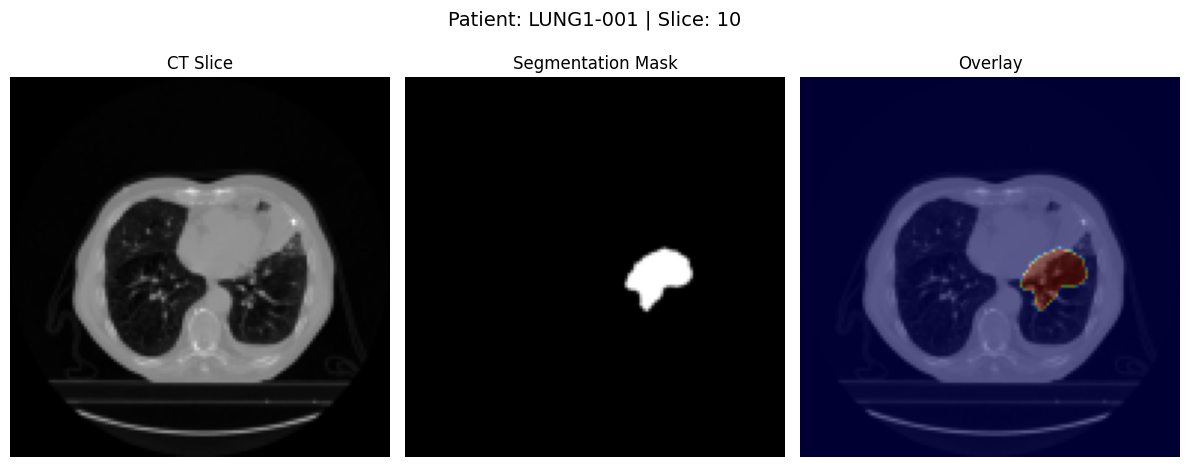

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# === Config ===
CT_DIR = r"C:\Lung_tumor_segmentation\preprocessed_cts_128x128"
MASK_DIR = r"C:\Lung_tumor_segmentation\preprocessed_masks_128x128"

def visualize_ct_and_mask(patient_id, slice_index=None):
    # Find all slices for this patient
    ct_files = sorted([f for f in os.listdir(CT_DIR) if f.startswith(patient_id) and f.endswith('.npy')])
    mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.startswith(patient_id) and f.endswith('.npy')])

    if not ct_files or not mask_files:
        print(f"[ERROR] No CT or Mask slices found for patient {patient_id}")
        return

    # Use middle slice if not specified
    if slice_index is None:
        slice_index = len(ct_files) // 2

    ct_file = os.path.join(CT_DIR, ct_files[slice_index])
    mask_file = os.path.join(MASK_DIR, mask_files[slice_index])

    ct_slice = np.load(ct_file)
    mask_slice = np.load(mask_file)

    # === Plot ===
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.title("CT Slice")
    plt.imshow(ct_slice, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Segmentation Mask")
    plt.imshow(mask_slice, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(ct_slice, cmap='gray')
    plt.imshow(mask_slice, cmap='jet', alpha=0.4)
    plt.axis("off")

    plt.suptitle(f"Patient: {patient_id} | Slice: {slice_index}", fontsize=14)
    plt.tight_layout()
    plt.show()

# === Example usage ===
visualize_ct_and_mask("LUNG1-001")  # Replace with the actual patient ID


### Dataset Loader V1:

In [ ]:
# import tensorflow as tf
# import numpy as np
# import glob
# import os
# from sklearn.model_selection import train_test_split

# # === Config ===
# CT_DIR = r"C:\Lung_tumor_segmentation\preprocessed_cts_128x128"
# MASK_DIR = r"C:\Lung_tumor_segmentation\preprocessed_masks_128x128"
# IMG_SIZE = (128, 128)
# BATCH_SIZE = 8
# BUFFER_SIZE = 100
# SEED = 42

# # === Step 1: Get paired file paths ===
# ct_files = {os.path.basename(f).replace("ct_", "").replace(".npy", ""): f for f in glob.glob(os.path.join(CT_DIR, "*.npy"))}
# mask_files = {os.path.basename(f).replace("mask_", "").replace(".npy", ""): f for f in glob.glob(os.path.join(MASK_DIR, "*.npy"))}

# common_keys = sorted(set(ct_files.keys()) & set(mask_files.keys()))
# ct_paths = [ct_files[k] for k in common_keys]
# mask_paths = [mask_files[k] for k in common_keys]

# print(f"[INFO] Using {len(ct_paths)} matched CT-Mask slice pairs")


# # === Step 2: Train-val split ===
# train_cts, val_cts, train_masks, val_masks = train_test_split(
#     ct_paths, mask_paths, test_size=0.2, random_state=SEED
# )

# # === Step 3: Define loader function ===
# def load_npy_pair(ct_path, mask_path):
#     def _load(path):
#         return np.load(path.decode("utf-8"))

#     ct = tf.numpy_function(_load, [ct_path], tf.float32)
#     mask = tf.numpy_function(_load, [mask_path], tf.float32)

#     ct.set_shape(IMG_SIZE)
#     mask.set_shape(IMG_SIZE)

#     # Normalize CT (HU windowing)
#     ct = tf.clip_by_value(ct, -1000, 400)
#     ct = (ct + 1000) / 1400.0  # normalize to [0, 1]

#     # Binarize mask
#     mask = tf.where(mask > 0, 1.0, 0.0)

#     # Add channel dimension
#     ct = tf.expand_dims(ct, axis=-1)
#     mask = tf.expand_dims(mask, axis=-1)

#     return ct, mask

# # === Step 4: Augmentation function ===
# def augment(ct, mask):
#     if tf.random.uniform(()) > 0.5:
#         ct = tf.image.flip_left_right(ct)
#         mask = tf.image.flip_left_right(mask)
#     return ct, mask

# # === Step 5: Create tf.data pipelines ===
# def create_dataset(ct_list, mask_list, training=True):
#     dataset = tf.data.Dataset.from_tensor_slices((ct_list, mask_list))
#     dataset = dataset.shuffle(BUFFER_SIZE, seed=SEED) if training else dataset
#     dataset = dataset.map(load_npy_pair, num_parallel_calls=tf.data.AUTOTUNE)
#     if training:
#         dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
#     dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
#     return dataset

# # === Step 6: Final datasets ===
# # === Step 6: Final datasets ===
# train_dataset = create_dataset(train_cts, train_masks, training=True)
# val_dataset = create_dataset(val_cts, val_masks, training=False)

# # train_dataset = train_dataset.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# # val_dataset = val_dataset.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


[INFO] Using 28064 matched CT-Mask slice pairs


### Data loader_v2

In [ ]:
import tensorflow as tf
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split

# === Config ===
CT_DIR = r"C:\Lung_tumor_segmentation\preprocessed_cts_128x128"
MASK_DIR = r"C:\Lung_tumor_segmentation\preprocessed_masks_128x128"
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
BUFFER_SIZE = 100
SEED = 42

# === Step 1: Get paired file paths ===
ct_files = {os.path.basename(f).replace("ct_", "").replace(".npy", ""): f for f in glob.glob(os.path.join(CT_DIR, "*.npy"))}
mask_files = {os.path.basename(f).replace("mask_", "").replace(".npy", ""): f for f in glob.glob(os.path.join(MASK_DIR, "*.npy"))}

common_keys = sorted(set(ct_files.keys()) & set(mask_files.keys()))
ct_paths = [ct_files[k] for k in common_keys]
mask_paths = [mask_files[k] for k in common_keys]

print(f"[INFO] Using {len(ct_paths)} matched CT-Mask slice pairs")

# === Step 2: Train-val split ===
train_cts, val_cts, train_masks, val_masks = train_test_split(
    ct_paths, mask_paths, test_size=0.2, random_state=SEED
)

# === Step 3: Define loader function ===
def load_npy_pair(ct_path:, mask_path):
    def _load(path)
        return np.load(path.numpy().decode("utf-8")).astype(np.float32)

    # Use tf.py_function instead of tf.numpy_function
    ct = tf.py_function(_load, [ct_path], tf.float32)
    mask = tf.py_function(_load, [mask_path], tf.float32)

    ct.set_shape(IMG_SIZE)
    mask.set_shape(IMG_SIZE)

    # Normalize CT (HU windowing)
    ct = tf.clip_by_value(ct, -1000.0, 400.0)
    ct = (ct + 1000.0) / 1400.0  # normalize to [0, 1]

    # Binarize mask
    mask = tf.where(mask > 0, 1.0, 0.0)

    # Add channel dimension
    ct = tf.expand_dims(ct, axis=-1)
    mask = tf.expand_dims(mask, axis=-1)

    return ct, mask

# === Step 4: Augmentation function ===
def augment(ct, mask):
    if tf.random.uniform(()) > 0.5:
        ct = tf.image.flip_left_right(ct)
        mask = tf.image.flip_left_right(mask)
    return ct, mask

# === Step 5: Create tf.data pipelines ===
def create_dataset(ct_list, mask_list, training=True):
    dataset = tf.data.Dataset.from_tensor_slices((ct_list, mask_list))

    if training:
        dataset = dataset.shuffle(BUFFER_SIZE, seed=SEED)

    dataset = dataset.map(
        lambda ct, mask: load_npy_pair(ct, mask),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# === Step 6: Final datasets ===
train_dataset = create_dataset(train_cts, train_masks, training=True)
val_dataset = create_dataset(val_cts, val_masks, training=False)


[INFO] Using 28064 matched CT-Mask slice pairs


In [34]:
for image, mask in train_dataset.take(1):
    print("Image shape:", image.shape)
    print("Mask shape:", mask.shape)


Image shape: (8, 128, 128, 1)
Mask shape: (8, 128, 128, 1)


=== Train Dataset Samples ===


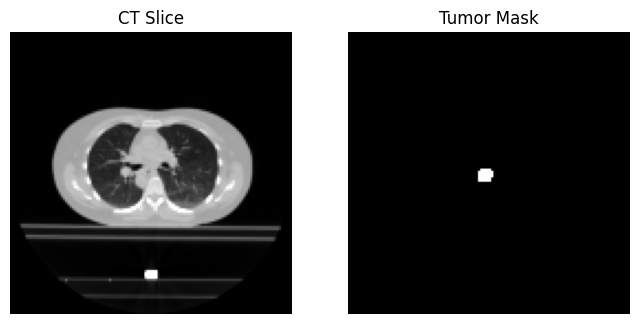

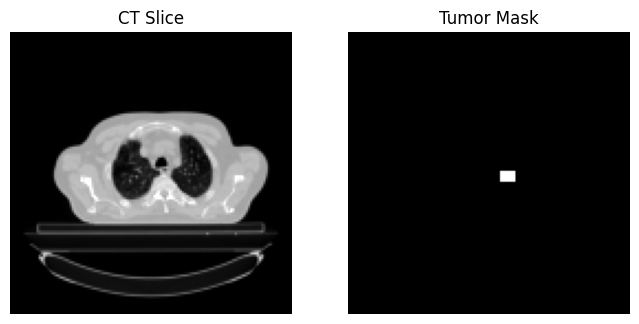

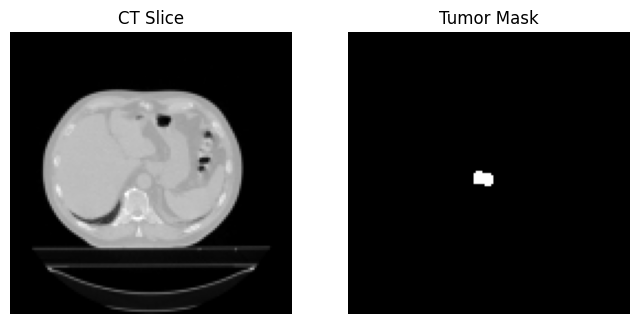

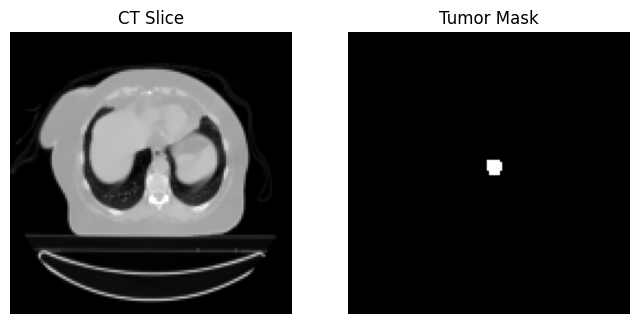

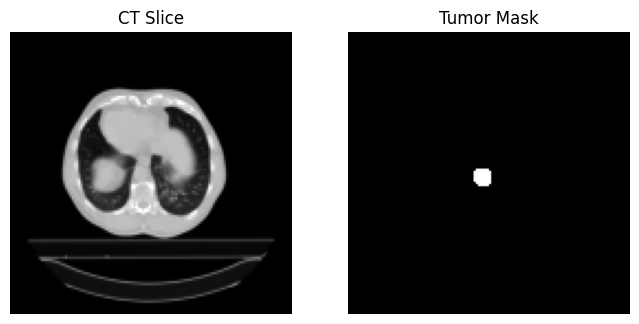

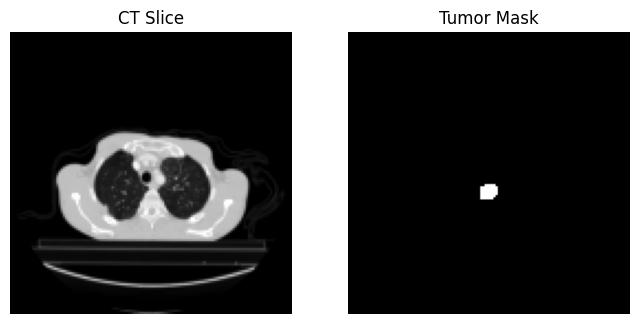

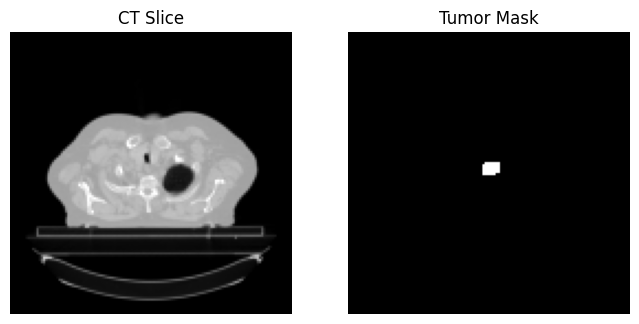

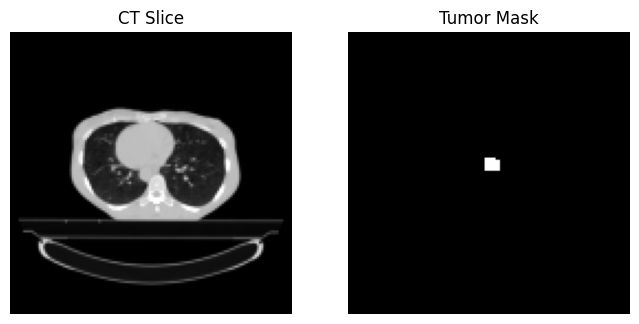

=== Validation Dataset Samples ===


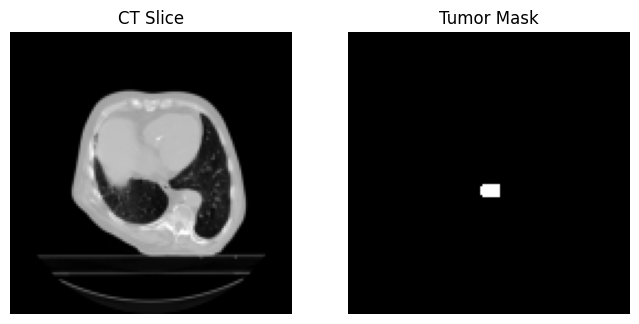

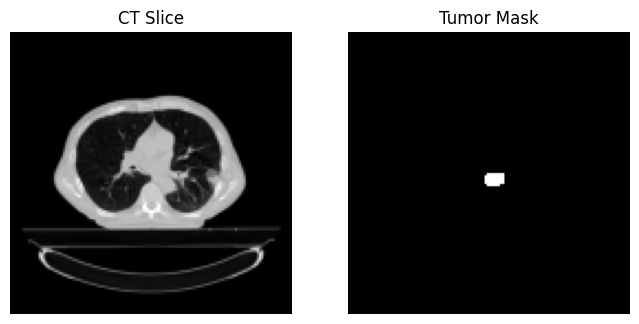

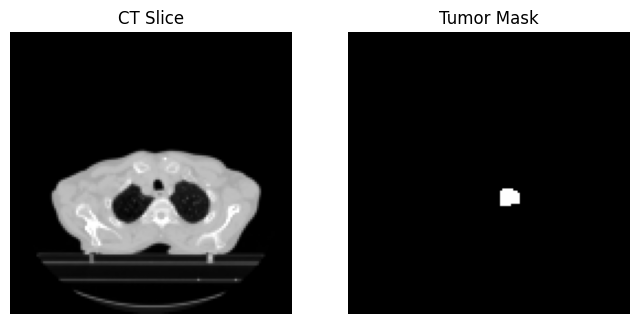

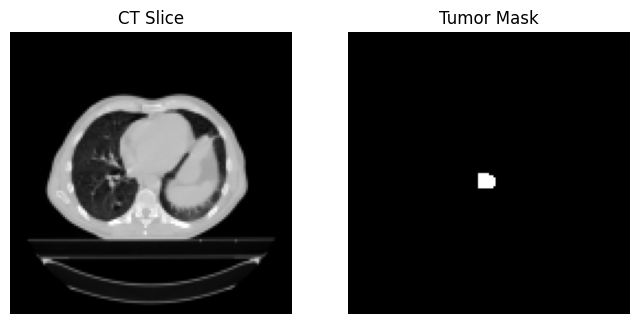

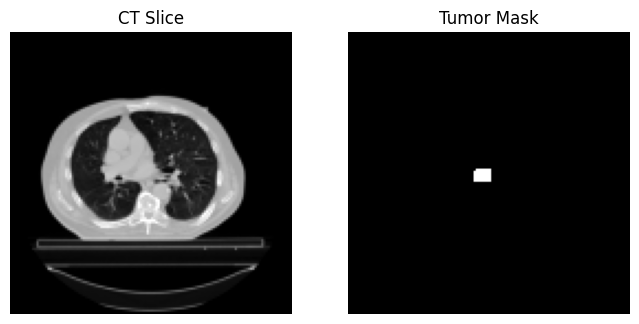

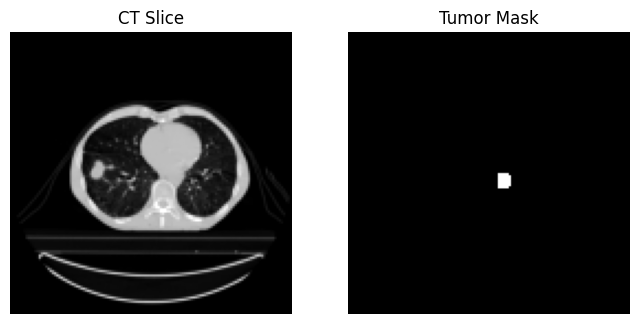

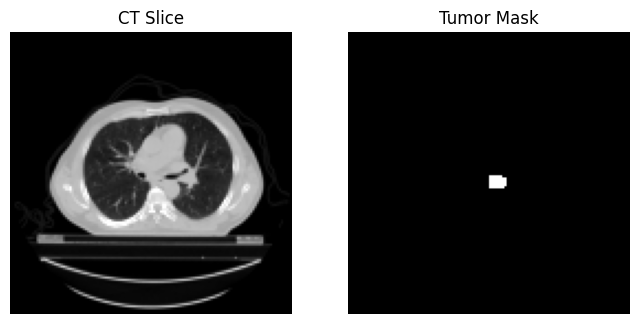

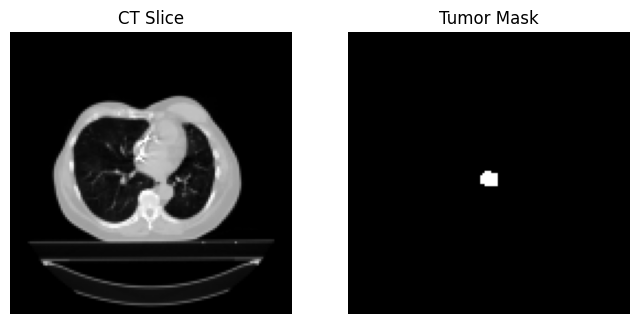

In [35]:
import matplotlib.pyplot as plt

def display_sample(dataset, num_batches=1):
    for batch in dataset.take(num_batches):
        images, masks = batch  # batch of images and masks
        for i in range(images.shape[0]):  # batch size
            image_np = images[i].numpy().squeeze()
            mask_np = masks[i].numpy().squeeze()

            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(image_np, cmap='gray')
            plt.title('CT Slice')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(mask_np, cmap='gray')
            plt.title('Tumor Mask')
            plt.axis('off')

            plt.show()

# Show samples from train dataset
print("=== Train Dataset Samples ===")
display_sample(train_dataset, num_batches=1)

# Show samples from validation dataset
print("=== Validation Dataset Samples ===")
display_sample(val_dataset, num_batches=1)


In [6]:
for image, mask in train_dataset.take(1):
    print("Image batch shape:", image.shape)
    print("Mask batch shape:", mask.shape)


Image batch shape: (8, 128, 128, 1)
Mask batch shape: (8, 128, 128, 1)


### Checking the imbalance

In [ ]:
import numpy as np
import glob
import os

mask_paths = sorted(glob.glob("preprocessed_masks_128x128/*.npy"))

num_with_tumor = 0
num_no_tumor = 0
total_positive_pixels = 0
total_pixels = 0

for path in mask_paths:
    mask = np.load(path)
    
    positive_pixels = np.sum(mask > 0.5)  # 1s (tumor)
    total = mask.size

    total_positive_pixels += positive_pixels
    total_pixels += total

    if positive_pixels > 0:
        num_with_tumor += 1
    else:
        num_no_tumor += 1

# === Print Report ===
print(f"Total mask files: {len(mask_paths)}")
print(f"Masks with tumor (positive class): {num_with_tumor}")
print(f"Masks with NO tumor (all background): {num_no_tumor}")
print(f"Ratio of tumor-positive masks: {num_with_tumor / len(mask_paths):.2f}")
print(f"Tumor pixels ratio (foreground vs total): {total_positive_pixels / total_pixels:.6f}")


Total mask files: 140491
Masks with tumor (positive class): 140491
Masks with NO tumor (all background): 0
Ratio of tumor-positive masks: 1.00
Tumor pixels ratio (foreground vs total): 0.022687


In [36]:
import glob
mask_paths = sorted(glob.glob("C:/Lung_tumor_segmentation/preprocessed_masks_128x128/*.npy"))
print(f"Total mask slices: {len(mask_paths)}")


Total mask slices: 140491


### Training the model with BCELoss and Dice loss Model_V1

In [24]:
# import tensorflow as tf
# from tensorflow.keras import layers, models, backend as K
# import os

# # === CONFIG ===
# INPUT_SHAPE = (128, 128, 1)
# BATCH_SIZE = 8
# EPOCHS = 5
# MODEL_PATH = 'best_model.h5'

# # === LOSS & METRICS ===
# def dice_coef(y_true, y_pred, smooth=1e-6):
#     y_true_f = tf.reshape(y_true, [-1])
#     y_pred_f = tf.reshape(y_pred, [-1])
#     intersection = tf.reduce_sum(y_true_f * y_pred_f)
#     return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# def dice_loss(y_true, y_pred):
#     return 1 - dice_coef(y_true, y_pred)

# def bce_dice_loss(y_true, y_pred):
#     bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
#     return bce + dice_loss(y_true, y_pred)

# # === U-Net with optional Attention ===
# def conv_block(x, filters):
#     x = layers.Conv2D(filters, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     x = layers.Conv2D(filters, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     return x

# def attention_gate(x, g, filters):
#     theta_x = layers.Conv2D(filters, 1)(x)
#     phi_g = layers.Conv2D(filters, 1)(g)
#     add = layers.add([theta_x, phi_g])
#     act = layers.Activation('relu')(add)
#     psi = layers.Conv2D(1, 1, activation='sigmoid')(act)
#     return layers.multiply([x, psi])

# def build_attention_unet(input_shape):
#     inputs = layers.Input(shape=input_shape)

#     # Encoder
#     c1 = conv_block(inputs, 64)
#     p1 = layers.MaxPooling2D()(c1)

#     c2 = conv_block(p1, 128)
#     p2 = layers.MaxPooling2D()(c2)

#     c3 = conv_block(p2, 256)
#     p3 = layers.MaxPooling2D()(c3)

#     c4 = conv_block(p3, 512)
#     p4 = layers.MaxPooling2D()(c4)

#     # Bottleneck
#     bn = conv_block(p4, 1024)

#     # Decoder
#     up4 = layers.Conv2DTranspose(512, 2, strides=2, padding='same')(bn)
#     att4 = attention_gate(c4, up4, 512)
#     concat4 = layers.concatenate([up4, att4])
#     c5 = conv_block(concat4, 512)

#     up3 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(c5)
#     att3 = attention_gate(c3, up3, 256)
#     concat3 = layers.concatenate([up3, att3])
#     c6 = conv_block(concat3, 256)

#     up2 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c6)
#     att2 = attention_gate(c2, up2, 128)
#     concat2 = layers.concatenate([up2, att2])
#     c7 = conv_block(concat2, 128)

#     up1 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c7)
#     att1 = attention_gate(c1, up1, 64)
#     concat1 = layers.concatenate([up1, att1])
#     c8 = conv_block(concat1, 64)

#     outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

#     return models.Model(inputs, outputs)

# # === Compile Model ===
# model = build_attention_unet(INPUT_SHAPE)
# model.compile(optimizer='adam', loss=bce_dice_loss, metrics=[dice_coef])
# model.summary()

# # === Callbacks ===
# callbacks = [
#     tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_dice_coef', mode='max'),
#     tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=10, restore_best_weights=True, mode='max'),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
# ]


# # === Train Model ===
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=EPOCHS,
#     callbacks=callbacks
# )


### Model V_2

In [28]:
# import tensorflow as tf
# from tensorflow.keras import layers, models
# import os

# # === CONFIG ===
# INPUT_SHAPE = (128, 128, 1)
# BATCH_SIZE = 8
# EPOCHS = 3
# MODEL_PATH = 'best_model.h5'

# # === LOSS & METRICS ===
# def dice_coef(y_true, y_pred, smooth=1e-6):
#     y_true_f = tf.reshape(y_true, [-1])
#     y_pred_f = tf.reshape(y_pred, [-1])
#     intersection = tf.reduce_sum(y_true_f * y_pred_f)
#     return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# def dice_loss(y_true, y_pred):
#     return 1 - dice_coef(y_true, y_pred)

# def bce_dice_loss(y_true, y_pred):
#     bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
#     return bce + dice_loss(y_true, y_pred)

# # === BLOCKS ===
# def conv_block(x, filters, dropout_rate=0.0):
#     x = layers.Conv2D(filters, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     if dropout_rate > 0:
#         x = layers.Dropout(dropout_rate)(x)

#     x = layers.Conv2D(filters, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     return x

# def attention_gate(x, g, filters):
#     theta_x = layers.Conv2D(filters, 1)(x)
#     phi_g = layers.Conv2D(filters, 1)(g)
#     add = layers.add([theta_x, phi_g])
#     act = layers.Activation('relu')(add)
#     psi = layers.Conv2D(1, 1, activation='sigmoid')(act)
#     return layers.multiply([x, psi])

# # === MODEL ===
# def build_attention_unet(input_shape):
#     inputs = layers.Input(shape=input_shape)

#     # Encoder
#     c1 = conv_block(inputs, 16)
#     p1 = layers.MaxPooling2D()(c1)

#     c2 = conv_block(p1, 32)
#     p2 = layers.MaxPooling2D()(c2)

#     c3 = conv_block(p2, 64, dropout_rate=0.1)
#     p3 = layers.MaxPooling2D()(c3)

#     c4 = conv_block(p3, 128, dropout_rate=0.1)
#     p4 = layers.MaxPooling2D()(c4)

#     # Bottleneck
#     bn = conv_block(p4, 256, dropout_rate=0.2)

#     # Decoder
#     up4 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(bn)
#     att4 = attention_gate(c4, up4, 128)
#     concat4 = layers.concatenate([up4, att4])
#     c5 = conv_block(concat4, 128, dropout_rate=0.1)

#     up3 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
#     att3 = attention_gate(c3, up3, 64)
#     concat3 = layers.concatenate([up3, att3])
#     c6 = conv_block(concat3, 64, dropout_rate=0.1)

#     up2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
#     att2 = attention_gate(c2, up2, 32)
#     concat2 = layers.concatenate([up2, att2])
#     c7 = conv_block(concat2, 32)

#     up1 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c7)
#     att1 = attention_gate(c1, up1, 16)
#     concat1 = layers.concatenate([up1, att1])
#     c8 = conv_block(concat1, 16)

#     outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

#     return models.Model(inputs, outputs)

# # === COMPILE MODEL ===
# model = build_attention_unet(INPUT_SHAPE)
# model.compile(optimizer='adam', loss=bce_dice_loss, metrics=[dice_coef])
# model.summary()

# # === CALLBACKS ===
# callbacks = [
#     tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_dice_coef', mode='max'),
#     tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=10, restore_best_weights=True, mode='max'),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
# ]

# # === DATASET PIPELINE ===
# # Make sure you already have these prepared:
# # train_dataset = create_dataset(train_cts, train_masks, training=True)
# # val_dataset = create_dataset(val_cts, val_masks, training=False)

# # Only do batching ONCE
# # train_dataset = train_dataset.take(30000 // BATCH_SIZE).batch(BATCH_SIZE)
# # val_dataset = val_dataset.take(5000 // BATCH_SIZE).batch(BATCH_SIZE)

# # === TRAIN MODEL ===
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=EPOCHS,
#     callbacks=callbacks,
#     verbose=1
# )


### Model_V3

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_403 (Conv2D) │ (None, 128, 128,  │        160 │ input_layer_13[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_403[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_234 (ReLU)    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_404 (Conv2D) │ (None, 128, 128,  │      2,320 │ re_lu_234[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_404[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_235 (ReLU)    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_52    │ (None, 64, 64,    │          0 │ re_lu_235[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_405 (Conv2D) │ (None, 64, 64,    │      4,640 │ max_pooling2d_52… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_405[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_236 (ReLU)    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_406 (Conv2D) │ (None, 64, 64,    │      9,248 │ re_lu_236[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_406[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_237 (ReLU)    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_53    │ (None, 32, 32,    │          0 │ re_lu_237[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_407 (Conv2D) │ (None, 32, 32,    │     18,496 │ max_pooling2d_53… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_407[0][0]

 Total params: 1,990,949 (7.59 MB)

 Trainable params: 1,988,005 (7.58 MB)

 Non-trainable params: 2,944 (11.50 KB)

Epoch 1/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 498s 172ms/step - dice_coef: 0.2070 - loss: 0.9314 - val_dice_coef: 0.4958 - val_loss: 0.5236 - learning_rate: 0.0010
Epoch 2/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 470s 167ms/step - dice_coef: 0.4894 - loss: 0.5301 - val_dice_coef: 0.5111 - val_loss: 0.5075 - learning_rate: 0.0010
Epoch 3/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 675s 240ms/step - dice_coef: 0.5080 - loss: 0.5108 - val_dice_coef: 0.5212 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 4/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 529s 189ms/step - dice_coef: 0.5246 - loss: 0.4936 - val_dice_coef: 0.5418 - val_loss: 0.4762 - learning_rate: 0.0010
Epoch 5/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 556s 198ms/step - dice_coef: 0.5406 - loss: 0.4771 - val_dice_coef: 0.5677 - val_loss: 0.4490 - learning_rate: 0.0010
Epoch 6/10
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 666s 235ms/step - dice_coef: 0.5590 - loss: 0.4581 - val_dice_coef: 0.5784 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 7/10
2807/2807 ━━━━━━━━━━━━━━━━━━━

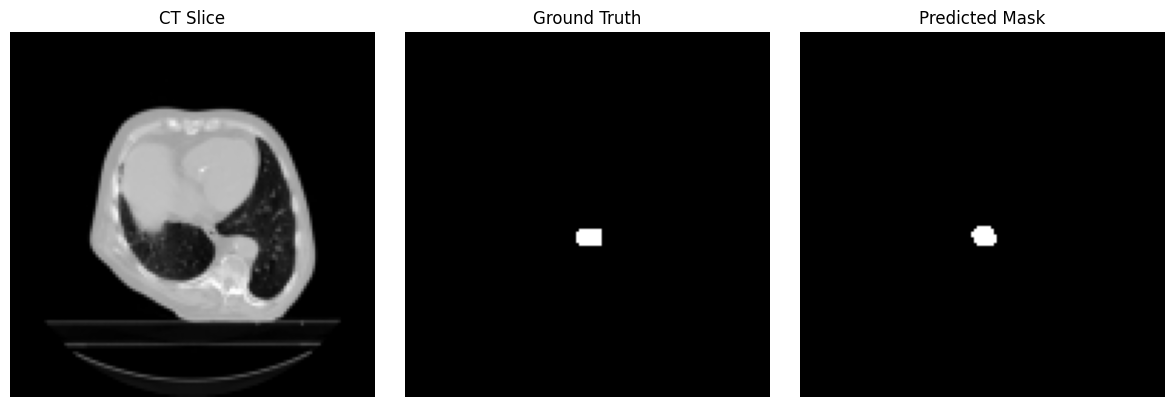

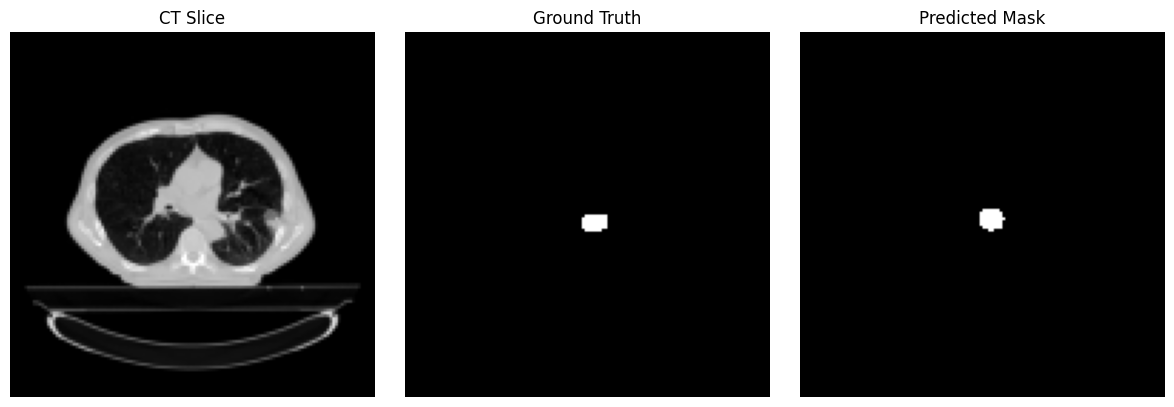

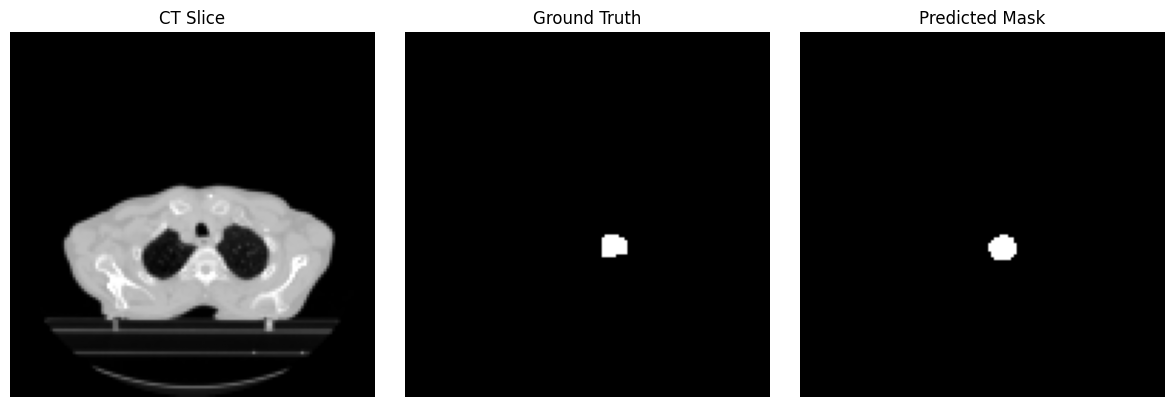

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
INPUT_SHAPE = (128, 128, 1)
BATCH_SIZE = 8
EPOCHS = 10  # Increased from 3 for better training
MODEL_PATH = 'best_model_3.keras'  # Updated from .h5 to recommended format

# === LOSS & METRICS ===
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# === BLOCKS ===
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, 1)(x) #This compresses encoder features x using a 1x1 convolution
    phi_g = layers.Conv2D(filters, 1)(g) #this applies the 1x1 conv to the output to the decoder or skip connection in the network reduces the depth of the layer
    add = layers.add([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, 1, activation='sigmoid')(act)
    return layers.multiply([x, psi])

# === MODEL ===
def build_attention_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 64, dropout_rate=0.1)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 128, dropout_rate=0.1)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, 256, dropout_rate=0.2)

    # Decoder It makes the image bigger again to match the original input size and combine detailed info.
    up4 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(bn)
    att4 = attention_gate(c4, up4, 128)
    concat4 = layers.concatenate([up4, att4])
    c5 = conv_block(concat4, 128, dropout_rate=0.1)

    up3 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
    att3 = attention_gate(c3, up3, 64)
    concat3 = layers.concatenate([up3, att3])
    c6 = conv_block(concat3, 64, dropout_rate=0.1)

    up2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
    att2 = 
    
    
    
    (c2, up2, 32)
    concat2 = layers.concatenate([up2, att2])
    c7 = conv_block(concat2, 32)

    up1 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c7)
    att1 = attention_gate(c1, up1, 16)
    concat1 = layers.concatenate([up1, att1])
    c8 = conv_block(concat1, 16)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

    return models.Model(inputs, outputs)

# === COMPILE MODEL ===
model = build_attention_unet(INPUT_SHAPE)
model.compile(optimizer='adam', loss=bce_dice_loss, metrics=[dice_coef])
model.summary()

# === CALLBACKS ===
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_dice_coef', mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=10, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

# === TRAINING ===
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# === PREDICTION & VISUALIZATION ===
# Take a batch from validation dataset
for x_batch, y_true_batch in val_dataset.take(1):
    y_pred_batch = model.predict(x_batch)

    # Visualize first 3 predictions
    for i in range(3):
        img = x_batch[i].numpy().squeeze()
        true_mask = y_true_batch[i].numpy().squeeze()
        pred_mask = y_pred_batch[i].squeeze()

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        plt.title('CT Slice')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask > 0.5, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')

        plt.tight_layout()
        plt.show()


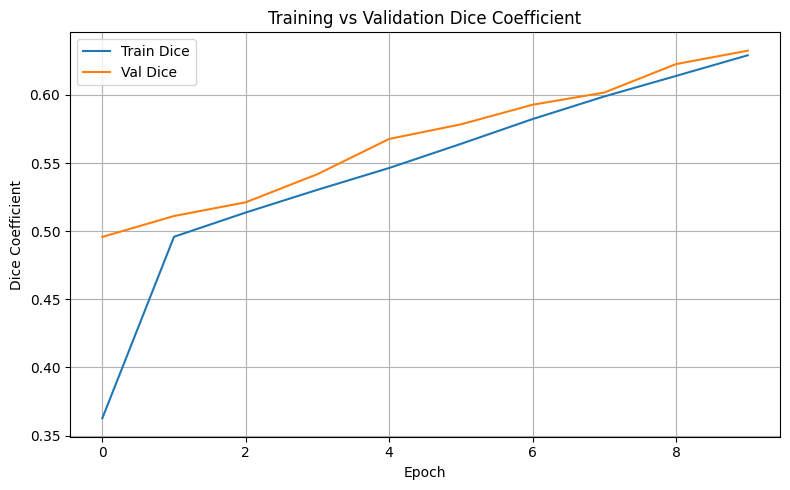

In [38]:
import matplotlib.pyplot as plt

def plot_dice(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['dice_coef'], label='Train Dice')
    plt.plot(history.history['val_dice_coef'], label='Val Dice')
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.title("Training vs Validation Dice Coefficient")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_dice(history)

### This training VS Validation Dice below is for 3 Epoch model version 1 only

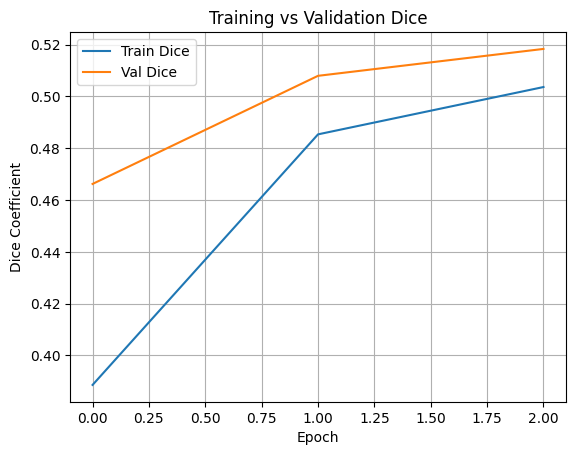

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Val Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def attention_gate(x, g, filters):
    theta_x = layers.Conv2D(filters, 1)(x)
    phi_g = layers.Conv2D(filters, 1)(g)
    add = layers.add([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, 1, activation='sigmoid')(act)
    return layers.multiply([x, psi])

# === MODEL ===
def build_attention_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 64, dropout_rate=0.1)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 128, dropout_rate=0.1)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, 256, dropout_rate=0.2)

    # Decoder
    up4 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(bn)
    att4 = attention_gate(c4, up4, 128)
    concat4 = layers.concatenate([up4, att4])
    c5 = conv_block(concat4, 128, dropout_rate=0.1)

    up3 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
    att3 = attention_gate(c3, up3, 64)
    concat3 = layers.concatenate([up3, att3])
    c6 = conv_block(concat3, 64, dropout_rate=0.1)

    up2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
    att2 = attention_gate(c2, up2, 32)
    concat2 = layers.concatenate([up2, att2])
    c7 = conv_block(concat2, 32)

    up1 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c7)
    att1 = attention_gate(c1, up1, 16)
    concat1 = layers.concatenate([up1, att1])
    c8 = conv_block(concat1, 16)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)

    return models.Model(inputs, outputs)

# Define the input shape for the model
INPUT_SHAPE = (128, 128, 1)  # 128x128 image size with 1 channel (grayscale)

# Now, create and compile the model
model = build_attention_unet(INPUT_SHAPE)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 1,990,949 (7.59 MB)

 Trainable params: 1,988,005 (7.58 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [14]:
from tensorflow.keras.utils import plot_model

# === Save model architecture as an image ===
plot_model(model, to_file='Lung_tumor_segmentation/model_architecture.png', show_shapes=True, show_layer_names=True)

print("Model architecture saved as 'model_architecture.png'.")


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Model architecture saved as 'model_architecture.png'.
